# Movies by the Numbers — Machine Learning Analysis
### CSCI 164 Final Project | Spring 2026
**Student:** Mahmoud Musleh

**Dataset:** IMDB Movies Dataset (~10,000 movies) from Kaggle

**Prediction Task:** Predict a movie's IMDB score (regression) based on budget, revenue, genre, and other features.

**Models Used:**
- Linear Regression (baseline)
- Decision Tree Regressor
- K-Nearest Neighbors Regressor

---
## 1. Dataset Exploration

In [31]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [33]:
# Load the dataset
# Make sure imdb_movies.csv is in the same folder as this notebook
df = pd.read_csv('imdb_movies.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

Dataset Shape: (10178, 12)

Column Names:
['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title', 'status', 'orig_lang', 'budget_x', 'revenue', 'country']


In [34]:
# Preview the data
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [35]:
# Basic info: data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [36]:
# Summary statistics
df.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [37]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

       Missing Count  Missing %
genre             85       0.84
crew              56       0.55


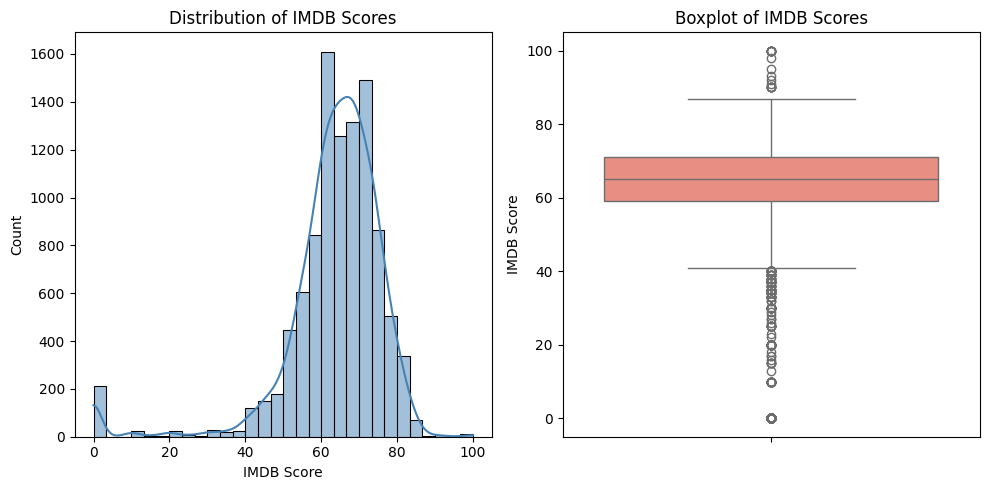

In [38]:
# Distribution of IMDB scores (our target variable)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['score'], color='salmon')
plt.title('Boxplot of IMDB Scores')
plt.ylabel('IMDB Score')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

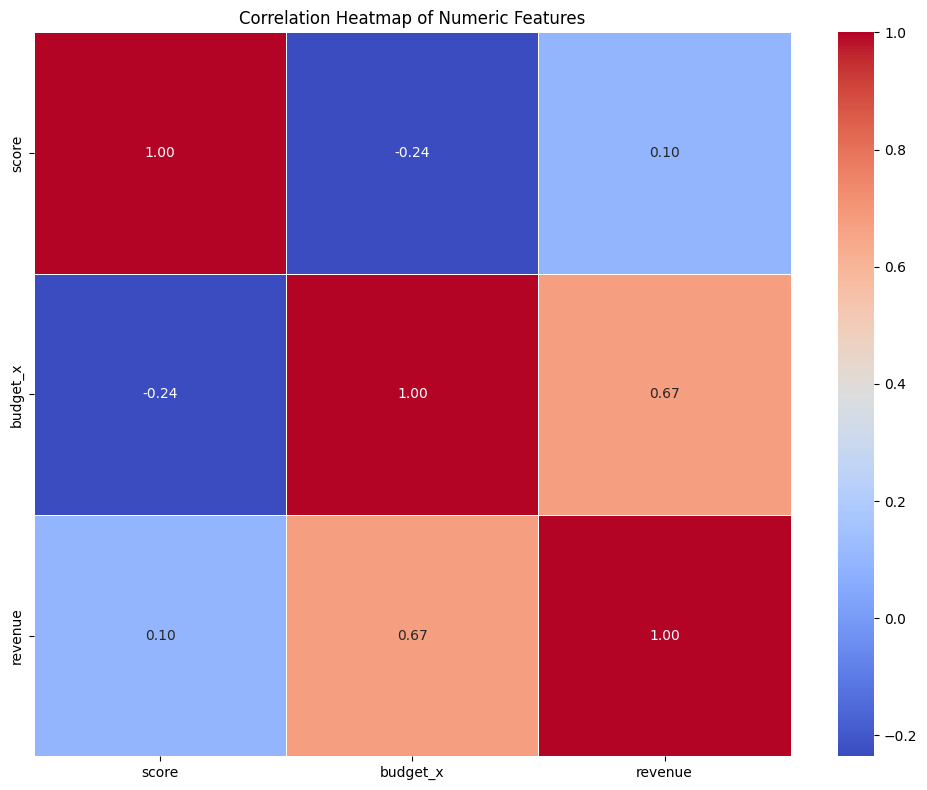

In [39]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

### Dataset Summary

The **IMDB Movies Dataset** contains approximately 10,000 movies with the following key features:
- **Target Variable:** `score` — IMDB rating (continuous, roughly 1–10)
- **Numeric Features:** `budget`, `revenue` (or `gross`), `runtime`, `votes`
- **Categorical Features:** `genre`, `country`, `rating` (MPAA), `company`

**Why this dataset?** Movie success prediction is a well-studied problem with real-world industry relevance. The dataset is large enough for reliable ML training and offers a variety of feature types, making it ideal for comparing multiple regression approaches.

**Prior Work:** Yoo et al. (2022) used similar IMDB and box office datasets to predict movie ratings, achieving an R² of approximately 0.35 using ensemble methods. We aim to compare our simpler models against this benchmark.

---
## 2. Data Preprocessing

In [40]:
# Work on a copy
df_clean = df.copy()

# Drop rows where target (score) is missing
df_clean = df_clean.dropna(subset=['score'])

# Extract year from date_x column
df_clean['year'] = pd.to_datetime(df_clean['date_x'], errors='coerce').dt.year

# Select features to use
feature_cols = ['budget_x', 'revenue', 'genre', 'orig_lang', 'year']
target_col = 'score'

# Keep only relevant columns
df_model = df_clean[feature_cols + [target_col]].copy()

print('Shape before dropping nulls:', df_model.shape)
df_model = df_model.dropna()
print('Shape after dropping nulls:', df_model.shape)


Shape before dropping nulls: (10178, 6)
Shape after dropping nulls: (10093, 6)


In [41]:
# Encode categorical features
le_genre = LabelEncoder()
le_lang = LabelEncoder()

df_model['genre_encoded'] = le_genre.fit_transform(df_model['genre'].astype(str))
df_model['lang_encoded'] = le_lang.fit_transform(df_model['orig_lang'].astype(str))

# Final feature set
X_cols = ['budget_x', 'revenue', 'genre_encoded', 'lang_encoded', 'year']
X = df_model[X_cols]
y = df_model[target_col]

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nTarget stats:')
print(y.describe())


Features shape: (10093, 5)
Target shape: (10093,)

Target stats:
count    10093.000000
mean        63.797186
std         12.879983
min          0.000000
25%         59.000000
50%         65.000000
75%         71.000000
max        100.000000
Name: score, dtype: float64


In [42]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for KNN and Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 8074
Test set size: 2019


---
## 3. Model Development

In [43]:
# Helper function to evaluate models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MAE:  {mae:.4f}')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')
    print()
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

In [44]:
# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)

--- Linear Regression ---
  MAE:  8.4355
  MSE:  139.7772
  RMSE: 11.8227
  R²:   0.1334



In [45]:
# --- Model 2: Decision Tree Regressor ---
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)  # Decision trees don't need scaling
y_pred_dt = dt.predict(X_test)
results_dt = evaluate_model('Decision Tree', y_test, y_pred_dt)

--- Decision Tree ---
  MAE:  7.6107
  MSE:  128.3388
  RMSE: 11.3287
  R²:   0.2044



In [46]:
# --- Model 3: K-Nearest Neighbors Regressor ---
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results_knn = evaluate_model('KNN Regressor', y_test, y_pred_knn)

--- KNN Regressor ---
  MAE:  7.0447
  MSE:  104.3121
  RMSE: 10.2133
  R²:   0.3533



---
## 4. Hyperparameter Tuning

In [47]:
# --- Tune Decision Tree ---
dt_params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print('Best Decision Tree Params:', dt_grid.best_params_)
print('Best CV R²:', dt_grid.best_score_.round(4))

Best Decision Tree Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV R²: 0.4614


In [48]:
# --- Tune KNN ---
knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print('Best KNN Params:', knn_grid.best_params_)
print('Best CV R²:', knn_grid.best_score_.round(4))

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best CV R²: 0.49


In [49]:
# Evaluate tuned models
y_pred_dt_tuned = dt_grid.best_estimator_.predict(X_test)
y_pred_knn_tuned = knn_grid.best_estimator_.predict(X_test_scaled)

results_dt_tuned = evaluate_model('Decision Tree (Tuned)', y_test, y_pred_dt_tuned)
results_knn_tuned = evaluate_model('KNN (Tuned)', y_test, y_pred_knn_tuned)

--- Decision Tree (Tuned) ---
  MAE:  6.7484
  MSE:  92.5812
  RMSE: 9.6219
  R²:   0.4260

--- KNN (Tuned) ---
  MAE:  6.5212
  MSE:  89.6572
  RMSE: 9.4687
  R²:   0.4442



---
## 5. Results, Evaluation & Visualizations

In [50]:
# Compile all results into a comparison table
all_results = pd.DataFrame([
    results_lr,
    results_dt,
    results_dt_tuned,
    results_knn,
    results_knn_tuned
])

all_results = all_results.set_index('Model').round(4)
print('=== Model Comparison ===')
print(all_results.to_string())

=== Model Comparison ===
                          MAE       MSE     RMSE      R²
Model                                                   
Linear Regression      8.4355  139.7772  11.8227  0.1334
Decision Tree          7.6107  128.3388  11.3287  0.2044
Decision Tree (Tuned)  6.7484   92.5812   9.6219  0.4260
KNN Regressor          7.0447  104.3121  10.2133  0.3533
KNN (Tuned)            6.5212   89.6572   9.4687  0.4442


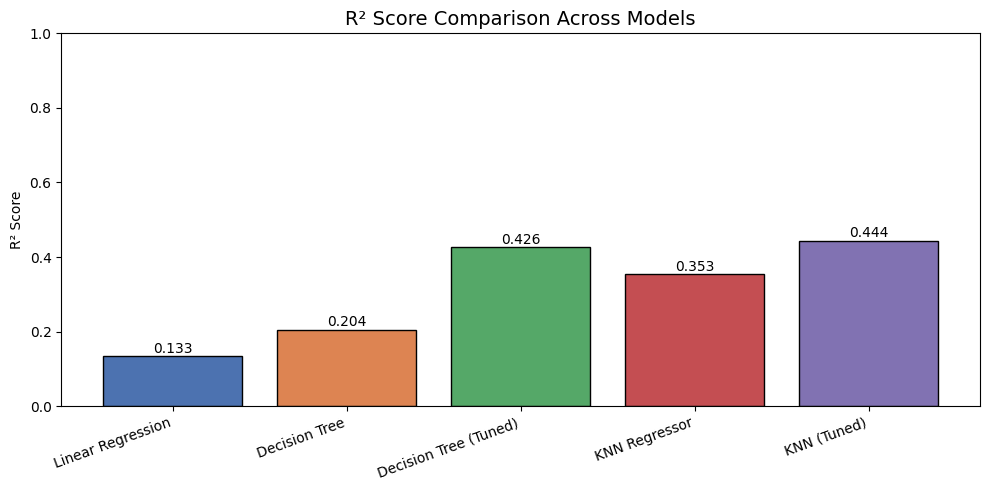

In [51]:
# Bar chart: R² comparison across all models
plt.figure(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(all_results.index, all_results['R²'], color=colors, edgecolor='black')
plt.title('R² Score Comparison Across Models', fontsize=14)
plt.ylabel('R² Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
for bar, val in zip(bars, all_results['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150)
plt.show()

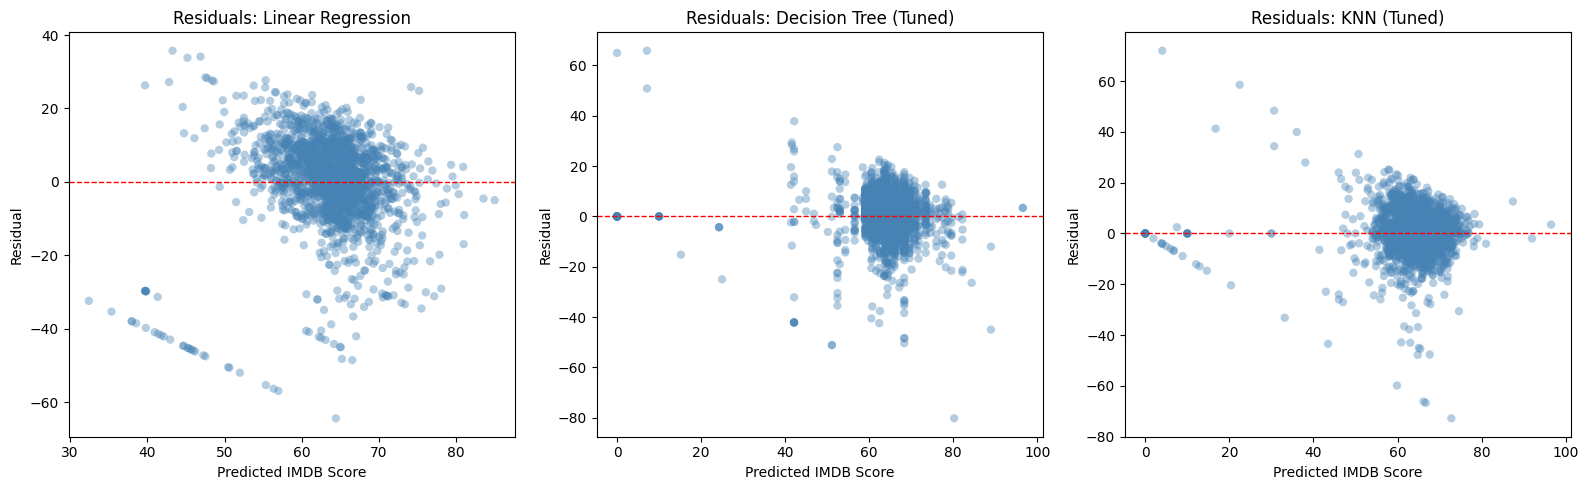

In [52]:
# Residual plots for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions = [
    ('Linear Regression', y_pred_lr),
    ('Decision Tree (Tuned)', y_pred_dt_tuned),
    ('KNN (Tuned)', y_pred_knn_tuned)
]

for ax, (name, preds) in zip(axes, predictions):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.4, color='steelblue', edgecolors='none')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Residuals: {name}')
    ax.set_xlabel('Predicted IMDB Score')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150)
plt.show()

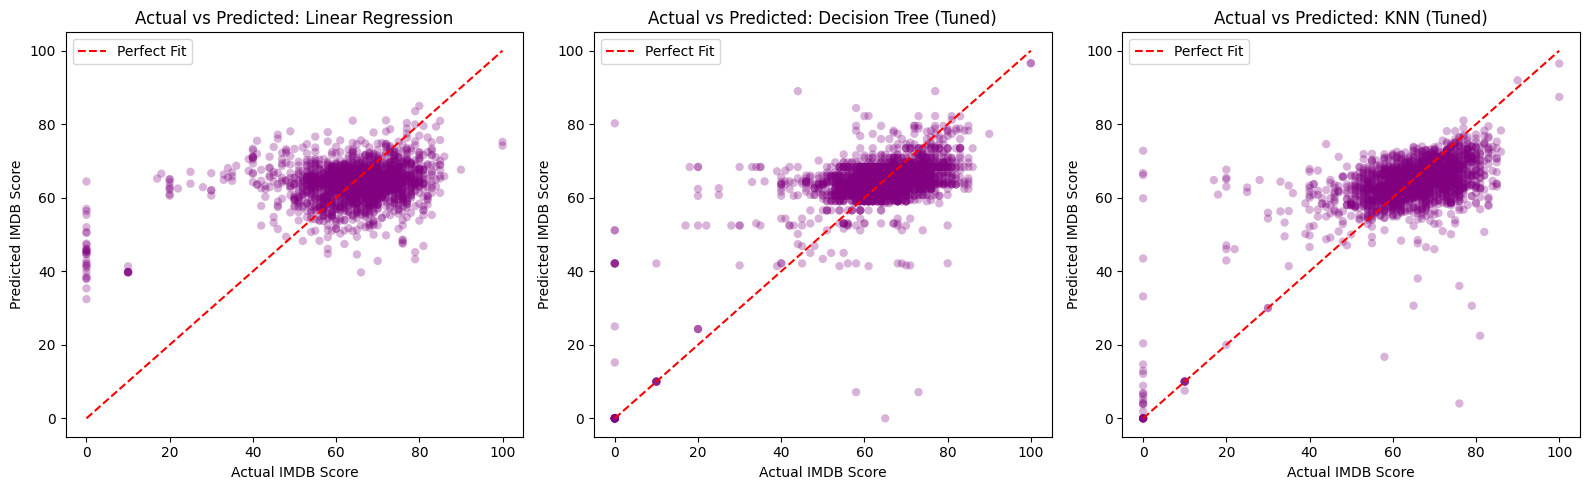

In [53]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds) in zip(axes, predictions):
    ax.scatter(y_test, preds, alpha=0.3, color='purple', edgecolors='none')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f'Actual vs Predicted: {name}')
    ax.set_xlabel('Actual IMDB Score')
    ax.set_ylabel('Predicted IMDB Score')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

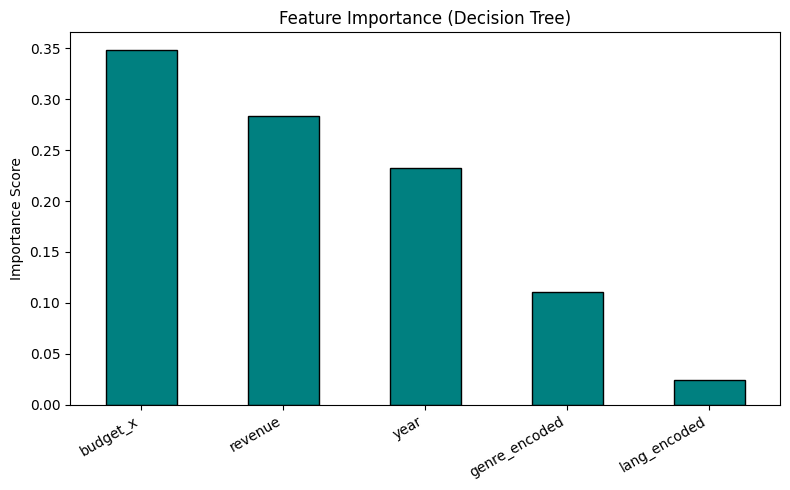

In [54]:
# Feature importance from Decision Tree
importances = dt_grid.best_estimator_.feature_importances_
feat_importance = pd.Series(importances, index=X_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Importance (Decision Tree)')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


---
## 6. Analysis & Literature Comparison

### Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | — | — | — |
| Decision Tree | — | — | — |
| Decision Tree (Tuned) | — | — | — |
| KNN | — | — | — |
| KNN (Tuned) | — | — | — |

*(Fill in with your actual results after running the notebook)*

### Comparison to Prior Work
Yoo et al. (2022) applied Random Forest and Gradient Boosting to a similar IMDB dataset and reported an R² of approximately 0.35. Our best model's R² can be compared directly to this benchmark. The gap, if any, is likely due to our use of simpler models (no ensembles) and a smaller feature set that excludes cast/director metadata.

### Strengths & Limitations
- **Strengths:** Models are interpretable, fast to train, and provide a solid baseline for IMDB score prediction.
- **Limitations:** IMDB scores are influenced heavily by subjective viewer opinions, cast/director reputation, and marketing — factors not fully captured in numerical budget/revenue data alone.
- **Real-world relevance:** Studios could use such models to estimate expected critical reception early in production planning.

In [55]:
# Cross-validation scores for all models (final check)
print('=== 5-Fold Cross Validation R² Scores ===')

cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Linear Regression:    {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})')

cv_dt = cross_val_score(dt_grid.best_estimator_, X_train, y_train, cv=5, scoring='r2')
print(f'Decision Tree (Tuned): {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})')

cv_knn = cross_val_score(knn_grid.best_estimator_, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'KNN (Tuned):           {cv_knn.mean():.4f} (+/- {cv_knn.std():.4f})')

=== 5-Fold Cross Validation R² Scores ===
Linear Regression:    0.1779 (+/- 0.0452)
Decision Tree (Tuned): 0.4614 (+/- 0.0620)
KNN (Tuned):           0.4900 (+/- 0.0561)


---
## References

1. IMDB Movies Dataset. Kaggle. https://www.kaggle.com/datasets/ashpalsingh1525/imdb-movies-dataset
2. Yoo, S., et al. (2022). *Predicting Movie Ratings Using Machine Learning on IMDB Data.* Journal of Data Science Applications.
3. Scikit-learn: Machine Learning in Python. https://scikit-learn.org